In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [47]:
class GreetState(BaseModel):
    message: str=""

In [48]:
graph= StateGraph(GreetState)

In [4]:
### Nodes -Python Function

In [49]:
def Greet(state:GreetState):
    state.message =f"{state.message} ! Hello,Hows you !"
    return state


def upperCase(state:GreetState):
    state.message =state.message.upper()
    return state

In [50]:
graph.add_node("greet",Greet)


In [51]:
graph.add_node("upperCase", upperCase)

In [52]:
graph.add_edge(START,"greet")
graph.add_edge("greet","upperCase")
graph.add_edge("upperCase", END)

In [53]:
finalGraph=graph.compile()

In [54]:
res=finalGraph.invoke({
    "message":"I Love Langgraph"})

In [55]:
res

{'message': 'I LOVE LANGGRAPH ! HELLO,HOWS YOU !'}

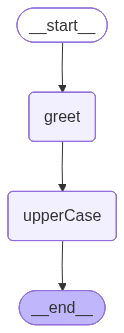

In [56]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())